# Simulated Annealing

Gradient-based methods follow the local slope at each step — they are blind to the global structure of the objective and inevitably settle in the nearest local minimum. **Simulated annealing (SA)** escapes local minima by accepting uphill moves with a probability that decreases over time. The acceptance rule is derived from **Markov chain theory**, making SA a controlled random walk whose stationary distribution concentrates on the global optimum as the temperature is lowered.

## The Problem with Gradient Methods

On a highly non-convex landscape, gradient descent converges to whichever local minimum is nearest to the starting point. There is no mechanism to escape: once $\|\nabla f(x_k)\|$ is small, the iterates are trapped. Any initialization-based workaround (random restarts) has no principled notion of "how far" to search.

We need an algorithm that:
1. Explores broadly when far from any minimum (global search), and
2. Exploits fine structure near a good minimum (local refinement).

Simulated annealing achieves both through a single temperature parameter that is gradually reduced.

## Markov Chain Foundation

*(Recall from Unit 3: a Markov chain on state space $\mathcal{X}$ has a stationary distribution $\pi$ if $\pi = \pi P$, where $P$ is the transition matrix. The chain is ergodic if it mixes to $\pi$ from any initial state.)*

### Target Distribution

We want the algorithm to spend more time near low values of $f$. The natural target is the **Boltzmann distribution**:

$$\pi_T(x) \propto \exp\!\left(-\frac{f(x)}{T}\right)$$

where $T > 0$ is the **temperature**.

- As $T \to \infty$: $\pi_T(x) \to \text{Uniform}$ — pure random exploration.
- As $T \to 0$: $\pi_T$ concentrates all mass on the global minimum $x^*$.

If we run a Markov chain with stationary distribution $\pi_T$ and slowly lower $T \to 0$, the chain tracks the global minimum.

### Metropolis–Hastings Acceptance Rule

To design a Markov chain with stationary distribution $\pi_T$, we use the **detailed balance** condition: for any two states $x$ and $x'$,

$$\pi_T(x)\, P(x \to x') = \pi_T(x')\, P(x' \to x)$$

The Metropolis–Hastings algorithm satisfies detailed balance with:
1. Propose a new state $x' = x + \varepsilon$, where $\varepsilon \sim \mathcal{N}(0, \sigma^2)$ (a symmetric proposal).
2. Accept $x'$ with probability

$$\boxed{P(\text{accept}) = \min\!\left(1,\; \exp\!\left(-\frac{f(x') - f(x)}{T}\right)\right)}$$

**Interpretation:**
- If $f(x') < f(x)$ (downhill move): acceptance probability $> 1$ — always accept.
- If $f(x') > f(x)$ (uphill move): accept with probability $\exp(-(\Delta f)/T) < 1$.

As $T \to 0$, uphill moves are never accepted — the algorithm becomes greedy descent. As $T$ increases, more uphill moves are accepted, enabling escape from local minima.

## Cooling Schedule

The temperature $T(t)$ controls the trade-off between exploration and exploitation. A common schedule is **exponential cooling**:

$$T(t) = T_0 \cdot e^{-t/\tau}$$

where $T_0$ is the initial temperature and $\tau$ is the cooling time constant.

- **Large $\tau$** (slow cooling): the chain has time to mix at each temperature — better solution quality, but slower.
- **Small $\tau$** (fast cooling): the chain freezes before mixing — quick, but likely trapped in a local minimum.

The theoretical guarantee for convergence to the global minimum requires cooling at rate $T(t) \geq C/\log(1 + t)$ — extremely slow. In practice, exponential cooling with a well-chosen $\tau$ performs well even without this guarantee.

The **acceptance rate** — fraction of proposals accepted — tracks $T$: near 1 when hot (random walk), near 0 when cold (greedy).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')
np.random.seed(42)


def simulated_annealing(f, x0, T0, tau, sigma, n_steps):
    """
    Simulated annealing for scalar or vector objective f.

    Parameters
    ----------
    f       : callable(x) -> float, objective to minimize
    x0      : float or ndarray, starting point
    T0      : float, initial temperature
    tau     : float, cooling time constant (T = T0 * exp(-t/tau))
    sigma   : float, proposal standard deviation
    n_steps : int, number of SA iterations

    Returns
    -------
    xs          : ndarray, iterate history
    fs          : ndarray, objective history
    accept_rate : float, overall acceptance rate
    """
    x = np.asarray(x0, dtype=float).copy()
    fx = f(x)
    xs = [x.copy()]; fs = [fx]
    n_accept = 0

    for t in range(1, n_steps + 1):
        T = T0 * np.exp(-t / tau)
        x_new = x + sigma * np.random.randn(*x.shape) if x.ndim else x + sigma * np.random.randn()
        fx_new = f(x_new)
        delta = fx_new - fx
        if delta < 0 or np.random.rand() < np.exp(-delta / max(T, 1e-10)):
            x = x_new; fx = fx_new
            n_accept += 1
        xs.append(x.copy()); fs.append(fx)

    return np.array(xs), np.array(fs), n_accept / n_steps


def gradient_descent(grad_f, x0, eta, n_steps, tol=1e-9):
    """Plain GD for comparison."""
    x = np.asarray(x0, dtype=float)
    history = [x.copy()]
    for _ in range(n_steps):
        g = np.asarray(grad_f(x), dtype=float)
        if np.linalg.norm(g) < tol:
            break
        x = x - eta * g
        history.append(x.copy())
    return history


## Toy 1D: Multi-Modal Landscape

We minimize $f(x) = |x| - \cos(10x)$, which has many local minima created by the cosine term and a global minimum near $x = 0$. The derivative is $f'(x) = \text{sign}(x) + 10\sin(10x)$ — gradient descent, starting from $x_0 = 3$, will find the nearest local minimum and stop. SA finds the global minimum by exploring broadly when hot.

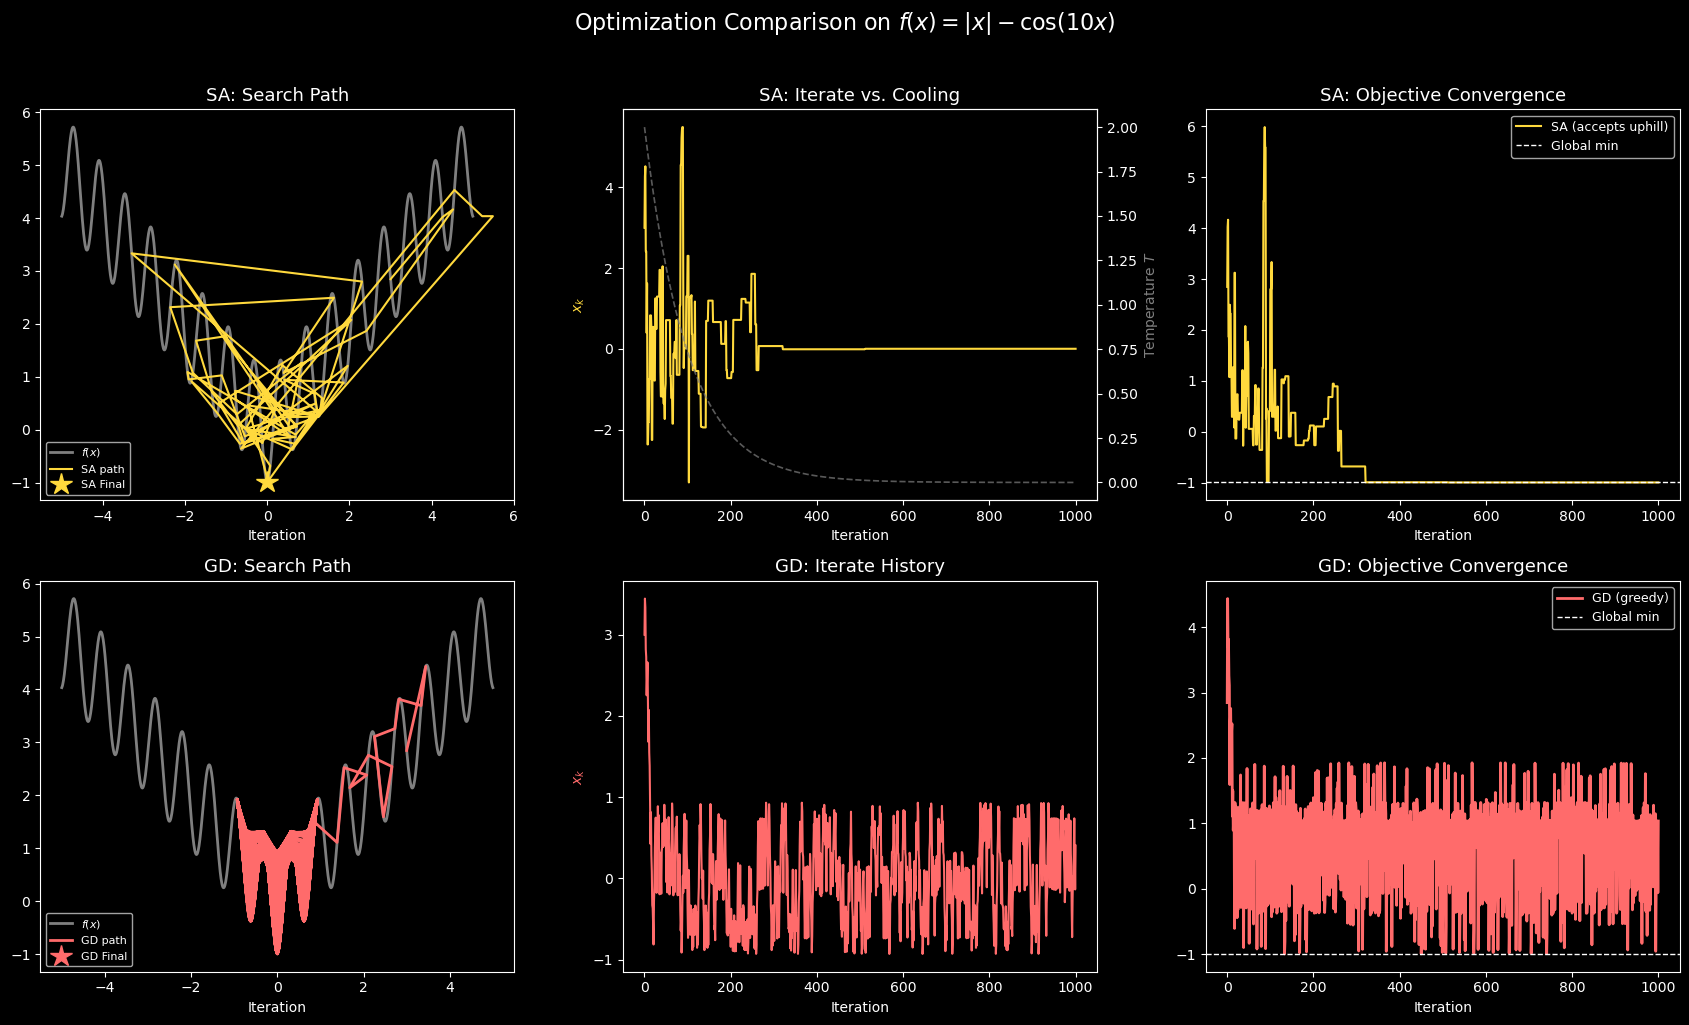

In [38]:
f1d  = lambda x: np.abs(x) - np.cos(10 * x)
df1d = lambda x: np.sign(x) + 10 * np.sin(10 * x)
grad1d = lambda x: np.array([df1d(x[0])])

x_grid = np.linspace(-5, 5, 1000)
x0_1d  = 3.0
T0_1d, tau_1d, sigma_1d = 2.0, 100, 3.0
N_STEPS = 1000

xs_sa, fs_sa, ar = simulated_annealing(f1d, x0_1d, T0_1d, tau_1d, sigma_1d, N_STEPS)
hist_gd = gradient_descent(grad1d, [x0_1d], 0.05, N_STEPS)
xs_gd   = np.array([h[0] for h in hist_gd])

T_curve = T0_1d * np.exp(-np.arange(N_STEPS + 1) / tau_1d)

# Create a 2-row, 3-column layout
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# --- ROW 1: SIMULATED ANNEALING ---
# 1. Landscape Path
axes[0, 0].plot(x_grid, f1d(x_grid), 'w-', lw=2, label='$f(x)$', alpha=0.5)
axes[0, 0].plot(xs_sa, f1d(np.clip(xs_sa, -5, 5)), color='#FFD93D', ms=2, label='SA path')
axes[0, 0].plot(xs_sa[-1], f1d(xs_sa[-1]), '*', color='#FFD93D', ms=16, label=f'SA Final')
axes[0, 0].set_title('SA: Search Path', fontsize=13)
axes[0, 0].legend(fontsize=8)

# 2. Iterate Trajectory + Temperature
ax_temp = axes[0, 1].twinx()
axes[0, 1].plot(xs_sa, '-', color='#FFD93D', lw=1.5, label='$x_k$ (SA)')
ax_temp.plot(T_curve, '--', color='gray', lw=1.2, alpha=0.7, label='Temp $T$')
axes[0, 1].set_title('SA: Iterate vs. Cooling', fontsize=13)
axes[0, 1].set_ylabel('$x_k$', color='#FFD93D')
ax_temp.set_ylabel('Temperature $T$', color='gray')

# 3. Objective Convergence
axes[0, 2].plot(fs_sa, '-', color='#FFD93D', lw=1.5, label='SA (accepts uphill)')
axes[0, 2].axhline(np.min(f1d(x_grid)), color='white', lw=1, ls='--', label='Global min')
axes[0, 2].set_title('SA: Objective Convergence', fontsize=13)
axes[0, 2].legend(fontsize=9)


# --- ROW 2: GRADIENT DESCENT ---
# 1. Landscape Path
axes[1, 0].plot(x_grid, f1d(x_grid), 'w', lw=2, label='$f(x)$', alpha=0.5)
axes[1, 0].plot(xs_gd, f1d(xs_gd), color='#FF6B6B', lw=2, label='GD path')
axes[1, 0].plot(xs_gd[-1], f1d(xs_gd[-1]), '*', color='#FF6B6B', ms=16, label=f'GD Final')
axes[1, 0].set_title('GD: Search Path', fontsize=13)
axes[1, 0].legend(fontsize=8)

# 2. Iterate Trajectory
axes[1, 1].plot(xs_gd, '-', color='#FF6B6B', lw=1.5, label='$x_k$ (GD)')
axes[1, 1].set_title('GD: Iterate History', fontsize=13)
axes[1, 1].set_ylabel('$x_k$', color='#FF6B6B')

# 3. Objective Convergence
axes[1, 2].plot(f1d(xs_gd), '-', color='#FF6B6B', lw=2, label='GD (greedy)')
axes[1, 2].axhline(np.min(f1d(x_grid)), color='white', lw=1, ls='--', label='Global min')
axes[1, 2].set_title('GD: Objective Convergence', fontsize=13)
axes[1, 2].legend(fontsize=9)

# Universal labels
for ax in axes.flat:
    ax.set_xlabel('Iteration')
    
plt.suptitle(
    fr'Optimization Comparison on $f(x) = |x| - \cos(10x)$',
    fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

## Cooling Schedule Analysis

The cooling rate $\tau$ controls how quickly the algorithm transitions from exploration to exploitation. Too fast and the chain freezes in a local minimum; too slow and the algorithm wastes time in the hot (random) phase. The plot below runs SA with several values of $\tau$ and shows the distribution of final solutions over 30 independent runs.

C:\Users\Graham West\AppData\Local\Temp\ipykernel_24956\4238453660.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([results[tau] for tau in taus],


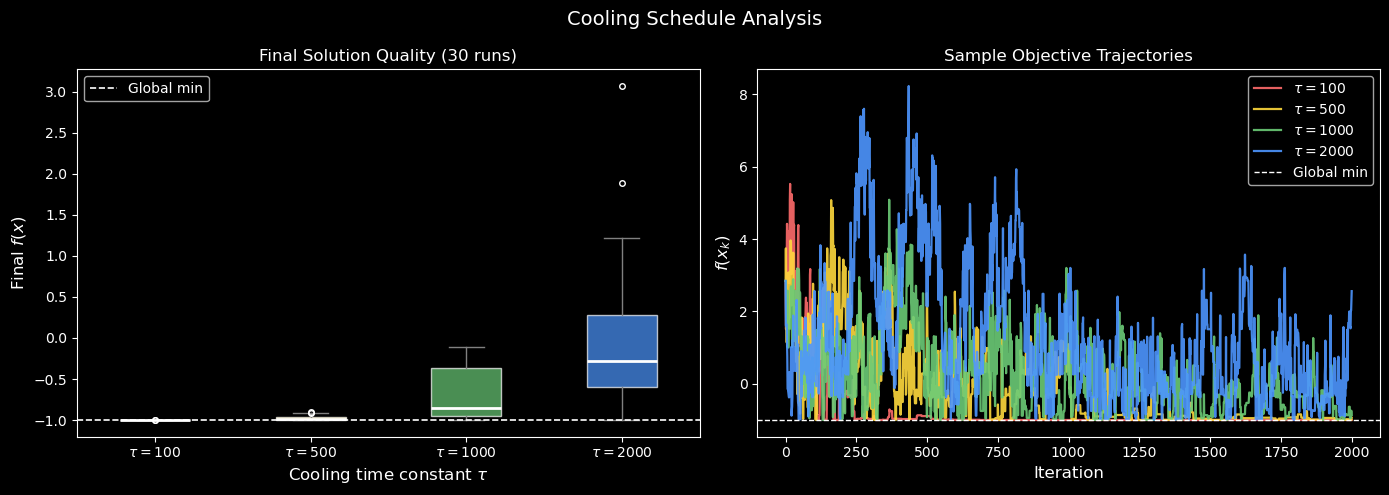

In [13]:
taus = [100, 500, 1000, 2000]
tau_colors = ['#FF6B6B', '#FFD93D', '#6BCB77', '#4D96FF']
N_RUNS = 30; N_STEPS_CS = 2000

results = {tau: [] for tau in taus}
for tau in taus:
    for _ in range(N_RUNS):
        xs_r, fs_r, _ = simulated_annealing(f1d, x0_1d, T0_1d, tau, sigma_1d, N_STEPS_CS)
        results[tau].append(f1d(xs_r[-1]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of final objective values
ax1.boxplot([results[tau] for tau in taus],
            labels=[f'$\\tau={tau}$' for tau in taus],
            patch_artist=True,
            boxprops=dict(facecolor='#333333'),
            medianprops=dict(color='white', lw=2),
            whiskerprops=dict(color='gray'),
            capprops=dict(color='gray'),
            flierprops=dict(marker='o', color='gray', ms=4))
for patch, col in zip(ax1.patches, tau_colors):
    patch.set_facecolor(col); patch.set_alpha(0.7)
ax1.axhline(f1d(0), color='white', ls='--', lw=1.2, label='Global min')
ax1.set_xlabel('Cooling time constant $\\tau$', fontsize=12)
ax1.set_ylabel('Final $f(x)$', fontsize=12)
ax1.set_title(f'Final Solution Quality ({N_RUNS} runs)', fontsize=12)
ax1.legend(fontsize=10)

# Sample convergence curves
ax2.set_title('Sample Objective Trajectories', fontsize=12)
for tau, col in zip(taus, tau_colors):
    xs_r, fs_r, _ = simulated_annealing(f1d, x0_1d, T0_1d, tau, sigma_1d, N_STEPS_CS)
    ax2.plot(fs_r, '-', color=col, lw=1.6, alpha=0.9, label=f'$\\tau={tau}$')
ax2.axhline(f1d(0), color='white', ls='--', lw=1, label='Global min')
ax2.set_xlabel('Iteration', fontsize=12); ax2.set_ylabel('$f(x_k)$', fontsize=12)
ax2.legend(fontsize=10)

plt.suptitle('Cooling Schedule Analysis', fontsize=14)
plt.tight_layout(); plt.show()


## Toy 2D: Non-Convex Landscape

We minimize a 2D multi-modal function constructed as a sum of Gaussian "wells" plus a bowl:

$$f(x, y) = 0.5(x^2 + y^2) - \sum_{i=1}^{6} A_i \exp\!\left(-\frac{(x-c_{xi})^2 + (y-c_{yi})^2}{2\sigma_i^2}\right)$$

This has a smooth bowl-shaped background with six local minima of varying depths. GD from a typical starting point converges to a local minimum; SA explores the landscape and finds a deeper one.

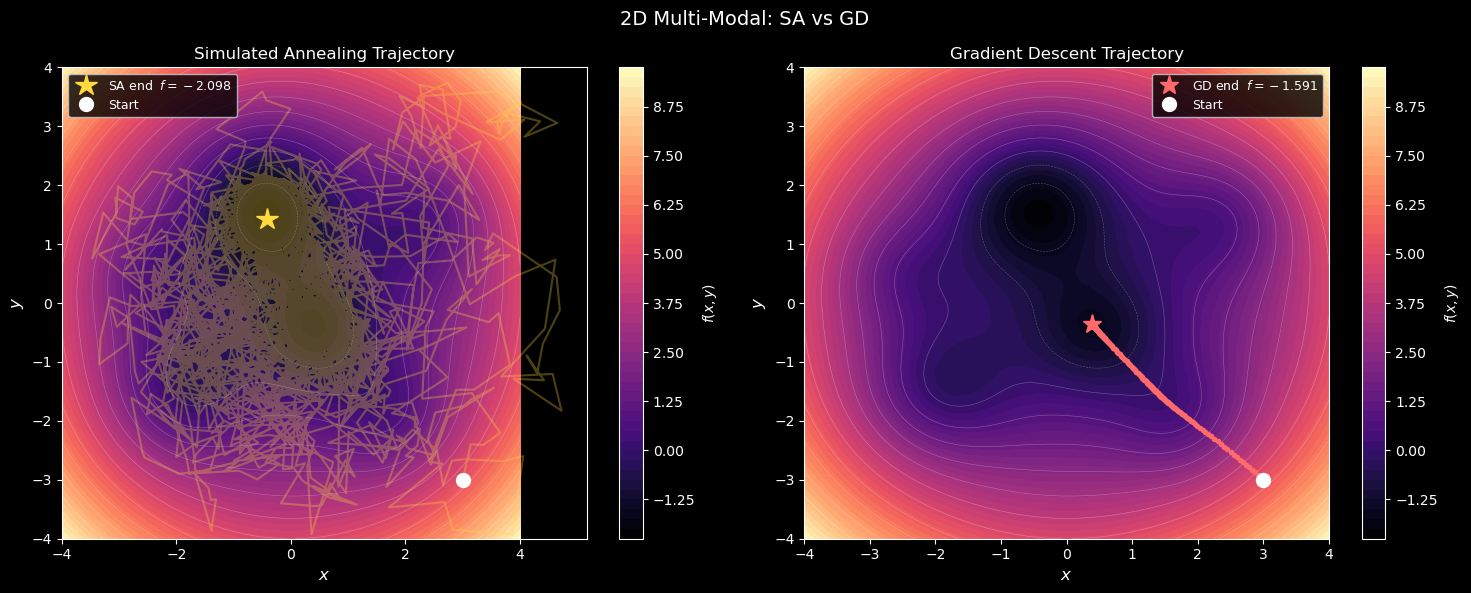

SA: f = -2.0975  at  x=-0.416, y=1.427,  accept rate=48.24%
GD: f = -1.5905  at  x=0.393, y=-0.362


In [15]:
# Define multi-modal 2D landscape
wells = [
    (2.0, (-2.0, -1.5), 0.8),
    (1.5, ( 1.8, -2.0), 0.7),
    (3.0, (-0.5,  1.8), 0.9),   # deepest well
    (1.8, ( 2.5,  1.5), 0.75),
    (1.2, (-2.5,  0.5), 0.65),
    (1.6, ( 0.5, -0.5), 0.70),
]

def f2d_mm(xy):
    x, y = xy[0], xy[1]
    bowl = 0.3 * (x**2 + y**2)
    return bowl - sum(A * np.exp(-((x - cx)**2 + (y - cy)**2) / (2 * s**2))
                      for A, (cx, cy), s in wells)

def grad_f2d_mm(xy):
    x, y = float(xy[0]), float(xy[1])
    dgx = 0.6 * x + sum(A * (x - cx) / s**2 * np.exp(-((x - cx)**2 + (y - cy)**2) / (2 * s**2))
                         for A, (cx, cy), s in wells)
    dgy = 0.6 * y + sum(A * (y - cy) / s**2 * np.exp(-((x - cx)**2 + (y - cy)**2) / (2 * s**2))
                         for A, (cx, cy), s in wells)
    return np.array([dgx, dgy])

xv2 = np.linspace(-4, 4, 300); yv2 = np.linspace(-4, 4, 300)
Xg2, Yg2 = np.meshgrid(xv2, yv2)
Zg2 = np.vectorize(lambda x, y: f2d_mm([x, y]))(Xg2, Yg2)

x0_2d_sa = np.array([3.0, -3.0])
xs_sa2, fs_sa2, ar2 = simulated_annealing(f2d_mm, x0_2d_sa, 3.0, 1200, 0.5, 5000)

hist_gd2 = gradient_descent(grad_f2d_mm, x0_2d_sa, 0.02, 500)
traj_gd2 = np.array(hist_gd2)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, traj, col, label in [
    (axes[0], None, None, 'SA'),
    (axes[1], traj_gd2, '#FF6B6B', 'GD')
]:
    cs = ax.contourf(Xg2, Yg2, Zg2, levels=50, cmap='magma')
    plt.colorbar(cs, ax=ax, label='$f(x,y)$')
    ax.contour(Xg2, Yg2, Zg2, levels=15, colors='white', linewidths=0.4, alpha=0.3)
    if label == 'SA':
        ax.plot(xs_sa2[:, 0], xs_sa2[:, 1], color='#FFD93D', ms=2, alpha=0.3)
        ax.plot(xs_sa2[-1, 0], xs_sa2[-1, 1], '*', color='#FFD93D', ms=16, zorder=6,
                label=f'SA end  $f={f2d_mm(xs_sa2[-1]):.3f}$')
        ax.set_title('Simulated Annealing Trajectory', fontsize=12)
    else:
        ax.plot(traj[:, 0], traj[:, 1], 'o-', color=col, ms=3, lw=1.5)
        ax.plot(traj[-1, 0], traj[-1, 1], '*', color=col, ms=14, zorder=6,
                label=f'GD end  $f={f2d_mm(traj[-1]):.3f}$')
        ax.set_title('Gradient Descent Trajectory', fontsize=12)
    ax.plot(*x0_2d_sa, 'wo', ms=10, zorder=5, label='Start')
    ax.set_xlabel('$x$', fontsize=12); ax.set_ylabel('$y$', fontsize=12)
    ax.legend(fontsize=9)

plt.suptitle('2D Multi-Modal: SA vs GD', fontsize=14)
plt.tight_layout(); plt.show()

print(f'SA: f = {f2d_mm(xs_sa2[-1]):.4f}  at  x={xs_sa2[-1][0]:.3f}, y={xs_sa2[-1][1]:.3f},  accept rate={ar2:.2%}')
print(f'GD: f = {f2d_mm(traj_gd2[-1]):.4f}  at  x={traj_gd2[-1][0]:.3f}, y={traj_gd2[-1][1]:.3f}')


## Application: Least Squares

We apply SA to the same least-squares problems as the GD notebooks.

**Linear regression** — the loss $\mathcal{L}(m,b)$ is convex, so GD is efficient and SA is unnecessary here (included for comparison).

**Nonlinear regression** — the exponential fit loss $\mathcal{L}(a,b)$ is non-convex. SA, being gradient-free, can sometimes find a better solution than GD when the loss has local traps.

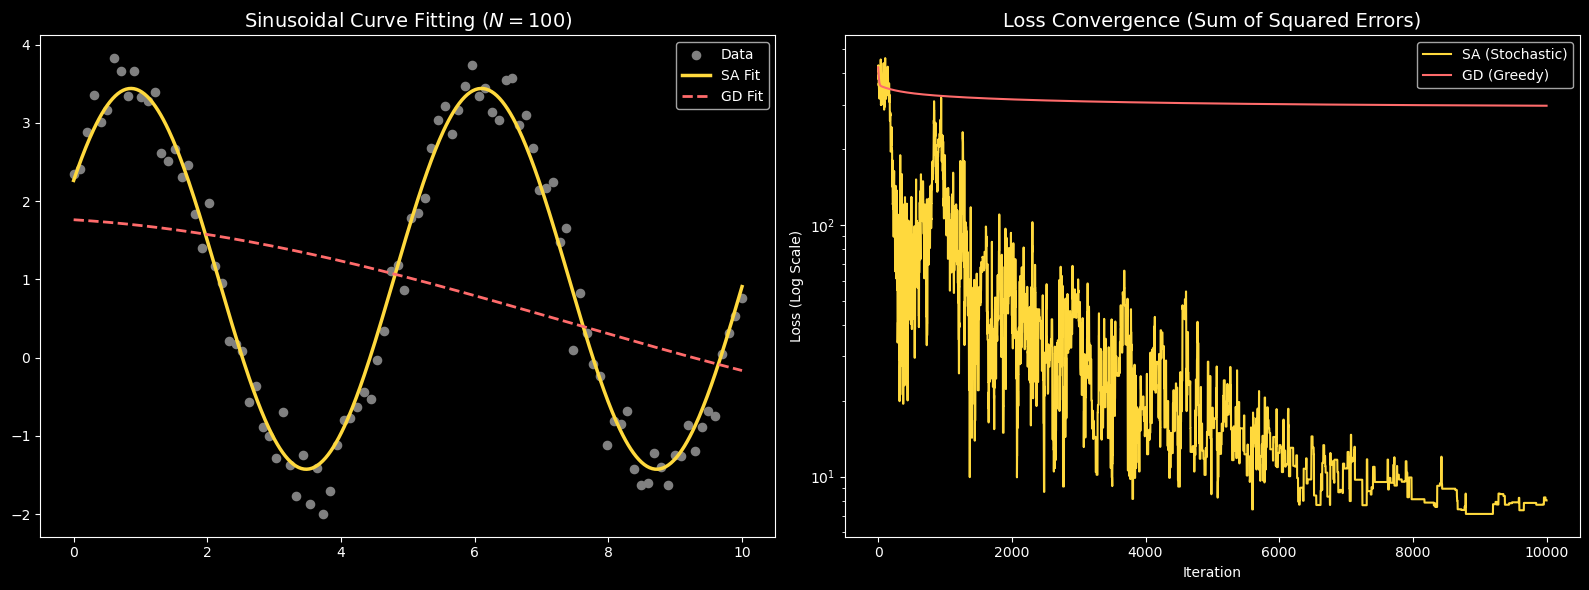

Parameter   | True       | SA         | GD        
---------------------------------------------
Amplitude   | 2.5000     | 2.4324     | 1.3416    
Freq (w)    | 1.2000     | -1.1982    | 0.1836    
Phase (phi) | 0.5000     | 2.5984     | 1.7822    
Offset (c)  | 1.0000     | 1.0078     | 0.4513    

SA Acceptance Rate: 17.98%


In [19]:
# 1. Generate Synthetic Sinusoidal Data
np.random.seed(42)
N = 100
x_data = np.linspace(0, 10, N)

# True parameters: Amplitude, Frequency, Phase, Vertical Offset
A_true, w_true, phi_true, c_true = 2.5, 1.2, 0.5, 1.0
y_data = A_true * np.sin(w_true * x_data + phi_true) + c_true + 0.3 * np.random.randn(N)

# 2. Define Loss and Gradient Functions
def loss_sin(params):
    A, w, phi, c = params
    pred = A * np.sin(w * x_data + phi) + c
    return np.sum((y_data - pred)**2)

def grad_sin(params):
    A, w, phi, c = params
    arg = w * x_data + phi
    sin_arg = np.sin(arg)
    cos_arg = np.cos(arg)
    
    resid = y_data - (A * sin_arg + c)
    
    dA = -2 * np.dot(sin_arg, resid)
    dw = -2 * np.dot(A * x_data * cos_arg, resid)
    dphi = -2 * np.dot(A * cos_arg, resid)
    dc = -2 * np.sum(resid)
    
    return np.array([dA, dw, dphi, dc])

# 3. Initialization and Hyperparameters
# Starting slightly off from truth to test escape/convergence
p0 = np.array([1.0, 0.5, 0.0, 0.0]) 
N_STEPS = 10000

# Simulated Annealing
# Note: sigma is vector-valued to handle different parameter scales
xs_sa, fs_sa, ar = simulated_annealing(loss_sin, p0, T0=50.0, tau=2000, sigma=0.1, n_steps=N_STEPS)

# Gradient Descent
# Using a very small learning rate as sinusoidal gradients can be explode/oscillate
hist_gd = gradient_descent(grad_sin, p0, eta=1e-5, n_steps=N_STEPS)
fs_gd = [loss_sin(p) for p in hist_gd]

# 4. Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: The Fit comparison
ax1 = axes[0]
ax1.scatter(x_data, y_data, color='gray', s=35, label='Data')
x_fine = np.linspace(0, 10, 500)

# SA Fit
A_sa, w_sa, phi_sa, c_sa = xs_sa[-1]
y_sa = A_sa * np.sin(w_sa * x_fine + phi_sa) + c_sa
ax1.plot(x_fine, y_sa, color='#FFD93D', lw=2.5, label='SA Fit')

# GD Fit
A_gd, w_gd, phi_gd, c_gd = hist_gd[-1]
y_gd = A_gd * np.sin(w_gd * x_fine + phi_gd) + c_gd
ax1.plot(x_fine, y_gd, color='#FF6B6B', lw=2, ls='--', label='GD Fit')

ax1.set_title(f'Sinusoidal Curve Fitting ($N={N}$)', fontsize=14)
ax1.legend()

# Plot B: Convergence (Log Loss)
ax2 = axes[1]
ax2.semilogy(fs_sa, color='#FFD93D', label='SA (Stochastic)')
ax2.semilogy(fs_gd, color='#FF6B6B', label='GD (Greedy)')
ax2.set_title('Loss Convergence (Sum of Squared Errors)', fontsize=14)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Loss (Log Scale)')
ax2.legend()

plt.tight_layout()
plt.show()

# 5. Output Results
print(f"{'Parameter':<11} | {'True':<10} | {'SA':<10} | {'GD':<10}")
print("-" * 45)
params_list = ["Amplitude", "Freq (w)", "Phase (phi)", "Offset (c)"]
true_vals = [A_true, w_true, phi_true, c_true]
sa_vals = xs_sa[-1]
gd_vals = hist_gd[-1]

for p, t, s, g in zip(params_list, true_vals, sa_vals, gd_vals):
    print(f"{p:<11} | {t:<10.4f} | {s:<10.4f} | {g:<10.4f}")

print(f"\nSA Acceptance Rate: {ar:.2%}")

## Summary

- **Simulated annealing** constructs a Markov chain whose stationary distribution is the Boltzmann distribution $\pi_T(x) \propto e^{-f(x)/T}$, which concentrates on the global minimum as $T \to 0$.
- The **Metropolis–Hastings acceptance rule** $P(\text{accept}) = \min(1, e^{-\Delta f / T})$ satisfies detailed balance — the core result from Unit 3 Markov chain theory.
- Lowering $T$ transitions the algorithm from exploration (random walk) to exploitation (greedy descent): SA is a controlled interpolation between the two regimes.
- On **multi-modal landscapes**, SA consistently finds deeper minima than gradient descent, which gets trapped at the nearest local minimum.
- The **cooling schedule** (choice of $\tau$) is the key tuning parameter: slower cooling yields better solutions at the cost of more iterations.
- SA is **gradient-free** — it only evaluates $f$, not $\nabla f$ — making it applicable to non-differentiable or black-box objectives where gradient methods fail.